# Does answering one `×0` problem correctly predict the next one?

The order asymmetry (`rt_zero_direction.ipynb`, `rt_direction_by_pair.ipynb`) says the zero rule is
*applied* faster when the 0 is met first. It says nothing about whether a student **has** the rule.
This notebook asks the accuracy question: within a student, does the first `×0` trial predict the
second one, and does that association survive the things that would explain it away — general
multiplication proficiency, general speed, exact repetition of the fact, repetition of the operand
order, and simple temporal proximity.

**This is observational and sequential, not causal.** Nothing here shows that answering Trial 1
correctly *makes* Trial 2 more likely to be correct. Trial 1 correctness is a *measurement* of the
student taken a few items earlier, so a positive association is first of all evidence that whatever
Trial 1 measures is stable. The interesting questions are comparative: does the association survive
a change of operand and of order (generalisation rather than fact repetition), and is it **larger for
`×0` than for ordinary multiplication** (specific to the rule rather than to being a good student).

**What the design allows.** A998 gives the median student 4 `×0` trials at a given age (p99 = 14), so
78% of first pairs sit inside one test, a median of 6 items apart, and the remaining 22% are months
apart. A998 gives **no feedback after a wrong answer** (confirmed with the product team, `DECISIONS #39`),
so Trial 1 correctness does not come with an instructional difference — the usual confound of this design
is absent here.

Queries: `queries/sequential_trials.sql` (kept multiplication trials with their position in the
student's sequence), `queries/student_controls.sql` (proficiency and speed measured outside the
`×0` problems), `queries/student_classroom.sql` (clustering). Filters as `DECISIONS.txt` #1–#11,
#15, #29–#34. ES_2025.

In [1]:
import logging, re, sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from pyfixest.estimation import feglm, feols
from scipy.stats import pearsonr

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from binary_stats import contrast_2x2, tetrachoric, tetrachoric_ci, wilson
from cached_query import cached_query
from plot_style import C_DIR, C_OTHER, C_TYPES, C_ZERO, FONT_BIG, FONT_MED, paint_it_black, set_style

PLOTS = ROOT / "analysis" / "plots"; PLOTS.mkdir(exist_ok=True)
Q = ROOT / "queries"
YEAR, CAP, SEED = "ES_2025", 14, 20260921
PT = ["zero", "one", "retrieval"]
LAB = {0: "×0", 1: "×1", 2: "retrieval"}
rng = np.random.default_rng(SEED)
set_style()
warnings.filterwarnings("ignore", message=".*singleton fixed effect.*")
warnings.filterwarnings("ignore", message="(?s).*multicollinearity.*")  # expected: a
# covariate is constant inside a by-age or by-condition subset and pyfixest says so, once per fit
for noisy in ("fontTools", "matplotlib.font_manager"):
    logging.getLogger(noisy).setLevel(logging.WARNING)
fmt = lambda p: "< .001" if p < .001 else f"= {p:.3f}"

In [2]:
def _sub(name, year=YEAR, cap=None):
    s = (Q / name).read_text(encoding="utf-8")
    s = re.sub(r"'[A-Z_0-9-]+'(\s+-- \{YEAR\})", f"'{year}'\\1", s)
    return s if cap is None else re.sub(r"<= \d+(\s+-- \{CAP\})", f"<= {cap}\\1", s)

def cq(name, **kw):
    return cached_query(Q / name, cache_dir=ROOT / "cache", sql_text=_sub(name, **kw))

def load(year=YEAR, cap=CAP):
    '''Kept multiplication trials carrying their position in the student's own sequence.'''
    cells = cq("rt_error_by_fact_age.sql", year=year)
    t = cq("sequential_trials.sql", year=year, cap=cap)
    ctl = cq("student_controls.sql", year=year).rename(columns={
        "acc_base": "level", "mean_lnrt_base": "speed", "acc_nr": "level_nr", "mean_lnrt_nr": "speed_nr"})
    cls = cq("student_classroom.sql", year=year)

    t["operation"] = t.left_factor.astype(str) + "×" + t.right_factor.astype(str)
    n_raw = len(t)
    t = t[pd.MultiIndex.from_arrays([t.course_age, t.operation])
            .isin(set(zip(cells.course_age, cells.operation)))]                        # >= 30 rule (#11)
    one_one = (t.ptype == "one") & (t.left_factor == 1) & (t.right_factor == 1)
    drop = {"below 30 per cell": n_raw - len(t), "0×0 (#15)": int((t.ptype == "zerozero").sum()),
            "1×1 (#31)": int(one_one.sum())}
    t = t[t.ptype.isin(PT) & ~one_one].copy()

    t = (t.merge(ctl[["student_uuid", "level", "speed", "level_nr", "speed_nr", "n_base", "n_nr"]],
                 on="student_uuid", how="left")
           .merge(cls[["student_uuid", "classroom_uuid"]], on="student_uuid", how="left"))
    for col in ("level", "speed", "level_nr", "speed_nr"):                             # z WITHIN age
        g = t.groupby("course_age")[col]
        t[col + "_z"] = ((t[col] - g.transform("mean")) / g.transform("std")).astype("float32")
    t["has_ctl"] = t.level_z.notna() & t.speed_z.notna()

    t["student"] = t.student_uuid.astype("category").cat.codes.astype("int32")
    t["classroom"] = t.classroom_uuid.astype("category").cat.codes.astype("int32")
    t["ptype_c"] = pd.Categorical(t.ptype, categories=PT).codes.astype("int8")
    t["day"] = t.response_at.astype("int64") / 86_400_000_000                          # days since epoch
    t["correct"] = t.statement_result.eq("Correct").astype("int8")
    rule = np.where(t.ptype_c == 0, 0, np.where(t.ptype_c == 1, 1, -1))                # the rule operand
    t["n_op"] = np.where(t.ptype_c == 2, -1, np.where(t.left_factor.values == rule,
                                                      t.right_factor, t.left_factor)).astype("int8")
    t["rule_second"] = np.where(t.ptype_c == 2, -1, t.right_factor.values == rule).astype("int8")
    t = t[["student", "classroom", "course_age", "ptype_c", "correct", "rt_seconds", "n_op",
           "rule_second", "left_factor", "right_factor", "pos_all", "cum_seconds", "metric_seq",
           "day", "level_z", "speed_z", "level_nr_z", "speed_nr_z", "has_ctl", "n_base"]]
    t = t.astype({"course_age": "int16", "left_factor": "int16", "right_factor": "int16",
                  "metric_seq": "int16", "pos_all": "int32", "rt_seconds": "float32",
                  "cum_seconds": "float32"})
    t = t.sort_values(["student", "course_age", "ptype_c", "pos_all"], kind="mergesort").reset_index(drop=True)
    t["trial_no"] = (t.groupby(["student", "course_age", "ptype_c"], sort=False).cumcount() + 1).astype("int16")
    return t, drop

t0 = time.time()
trials, drop = load()
print(f"loaded in {time.time()-t0:.0f}s | dropped: " + ", ".join(f"{k} {v:,}" for k, v in drop.items()))
print(f"{len(trials):,} kept trials | {trials.student.nunique():,} students | "
      f"{trials.classroom.nunique():,} classrooms | controls for "
      f"{trials.loc[trials.has_ctl, 'student'].nunique():,} students | "
      f"{trials.memory_usage(deep=True).sum()/1e6:.0f} MB")

loaded in 17s | dropped: below 30 per cell 72, 0×0 (#15) 28,064, 1×1 (#31) 27,982
3,214,990 kept trials | 171,840 students | 9,230 classrooms | controls for 96,654 students | 215 MB


## 1. The sample

Ages are kept apart throughout: a pair is two trials of the same student **at the same course age**,
and the primary analysis uses each student's **chronologically first two** `×0` trials, so every
student contributes exactly one pair and a student with 14 trials does not outweigh one with two.
Age 8 never appears — the test administers no `×0` items there (`DECISIONS #12`).

In [3]:
z = trials[trials.ptype_c == 0]
cov = z.groupby("course_age").agg(trials=("correct", "size"), students=("student", "nunique"),
                                  accuracy=("correct", "mean"))
cov["per_student"] = (cov.trials / cov.students).round(2)
cov["with_2_or_more"] = z.groupby(["course_age", "student"]).size().ge(2).groupby("course_age").sum()
cov["pct_usable"] = (100 * cov.with_2_or_more / cov.students).round(1)
display(cov.round({"accuracy": 4}))
print(f"×0 trials per student: median {z.groupby(['student','course_age']).size().median():.0f}, "
      f"p99 {z.groupby(['student','course_age']).size().quantile(.99):.0f}, "
      f"max {z.groupby(['student','course_age']).size().max()} (the query caps at {CAP})")

,trials,students,accuracy,per_student,with_2_or_more,pct_usable
course_age,,,,,,
9,34498,17818,0.7965,1.94,9926,55.7
10,131681,31560,0.8692,4.17,27001,85.6
11,148392,32013,0.8918,4.64,28021,87.5
12,68648,12243,0.9074,5.61,11194,91.4
13,70297,11155,0.9237,6.30,10468,93.8
14,35955,5649,0.9464,6.36,5262,93.1
15,10363,1971,0.9690,5.26,1791,90.9


×0 trials per student: median 4, p99 14, max 14 (the query caps at 14)


## 2. The two student-level controls

Both are estimated **outside the `×0` problems**, so they cannot absorb what is being tested:

- `level` — accuracy over every kept response to a fact with no zero operand;
- `speed` — mean log RT over the correct ones (higher = **slower**).

Both standardised within age, so they carry no age information. `student_controls.sql` requires at
least 20 non-`×0` trials behind a control, which is why the adjusted models run on a subset of the
descriptive sample; the unadjusted contrast is reported in both so the subsetting can be judged.

In [4]:
def build_pairs(t):
    '''Every consecutive transition within student × age × problem type.'''
    key = t.student.values.astype("int64") * 1000 + t.course_age.values * 10 + t.ptype_c.values
    i = np.flatnonzero(key[:-1] == key[1:]); j = i + 1
    g = lambda c: t[c].values
    p = pd.DataFrame({
        "student": g("student")[i], "classroom": g("classroom")[i], "course_age": g("course_age")[i],
        "ptype_c": g("ptype_c")[i], "pair_no": g("trial_no")[i],
        "c1": g("correct")[i].astype("float64"), "c2": g("correct")[j].astype("float64"),
        "rt1": g("rt_seconds")[i], "rt2": g("rt_seconds")[j],
        "n1": g("n_op")[i], "n2": g("n_op")[j], "ord1": g("rule_second")[i], "ord2": g("rule_second")[j],
        "a1": g("left_factor")[i], "b1": g("right_factor")[i],
        "a2": g("left_factor")[j], "b2": g("right_factor")[j],
        "trials_between": (g("pos_all")[j] - g("pos_all")[i] - 1).astype("int32"),
        "same_test": (g("metric_seq")[j] == g("metric_seq")[i]).astype("float64"),
        "gap_s": np.where(g("metric_seq")[j] == g("metric_seq")[i],
                          g("cum_seconds")[j] - g("cum_seconds")[i], np.nan),
        "gap_days": g("day")[j] - g("day")[i],
        "level_z": g("level_z")[i], "speed_z": g("speed_z")[i],
        "level_nr_z": g("level_nr_z")[i], "speed_nr_z": g("speed_nr_z")[i], "has_ctl": g("has_ctl")[i]})
    p["same_operand"] = np.where(p.ptype_c == 2, -1.0, (p.n1 == p.n2).astype(float))
    p["same_order"] = np.where(p.ptype_c == 2, -1.0, (p.ord1 == p.ord2).astype(float))
    p["same_fact"] = ((p.a1 == p.a2) & (p.b1 == p.b2)).astype(float)
    p["same_pair"] = ((np.minimum(p.a1, p.b1) == np.minimum(p.a2, p.b2)) &
                      (np.maximum(p.a1, p.b1) == np.maximum(p.a2, p.b2))).astype(float)
    p["age_c"] = (p.course_age - 11).astype("float64")
    p["log_between"] = np.log10(1 + p.trials_between.clip(lower=0))
    p["log_rt1"] = np.log(p.rt1)
    p["cond4"] = np.where(p.ptype_c == 2, "-", np.where(
        p.same_operand == 1, np.where(p.same_order == 1, "A same n, same order", "B same n, switched"),
        np.where(p.same_order == 1, "C diff n, same order", "D diff n, switched")))
    p["t_one"] = (p.ptype_c == 1).astype("float64")
    p["t_ret"] = (p.ptype_c == 2).astype("float64")
    return p

def dummies(d):
    '''Trial-2 operand dummies, reference n = 1. Built on the analysis subsets, not on all 2.8M rows.'''
    return d.assign(**{f"n2_{k}": (d.n2 == k).astype("float64") for k in range(2, 10)})

pairs = build_pairs(trials)
first = pairs[pairs.pair_no == 1]
z0 = dummies(first[first.ptype_c == 0]).reset_index(drop=True)           # THE primary sample
m = z0[z0.has_ctl].reset_index(drop=True)                                # with controls
print(pairs.groupby("ptype_c").agg(transitions=("c2", "size"), students=("student", "nunique")).rename(index=LAB))
print(f"\nprimary sample: {len(z0):,} students, one pair each, {z0.classroom.nunique():,} classrooms")
print(f"adjusted sample: {len(m):,} students ({100*len(m)/len(z0):.0f}%), {m.classroom.nunique():,} classrooms")
print(f"pairs inside one test: {100*z0.same_test.mean():.1f}% | median items between the two trials: "
      f"{z0.trials_between.median():.0f}")

           transitions  students
ptype_c                         
×0              387425     93663
×1              509550    136789
retrieval      1874970    170216

primary sample: 93,663 students, one pair each, 6,874 classrooms
adjusted sample: 55,033 students (59%), 6,256 classrooms
pairs inside one test: 78.0% | median items between the two trials: 6


## 3. The raw association

`P(Trial 2 correct | Trial 1 correct)` against `P(Trial 2 correct | Trial 1 incorrect)`, one student
one pair. Wilson intervals on each probability, Newcombe hybrid-score interval on the difference.

In [5]:
def table(groups):
    return pd.DataFrame({k: contrast_2x2(g.c1, g.c2) for k, g in groups}).T

desc = pd.concat([table([("All ages", z0)]), table([(f"Age {a}", g) for a, g in z0.groupby("course_age")])])
R2 = {c: 2 for c in ["pC2C1", "C1lo", "C1hi", "pC2E1", "E1lo", "E1hi", "diff", "dlo", "dhi",
                     "OR", "ORlo", "ORhi"]} | {"RR": 3}
display(desc.round(R2))
overall = desc.loc["All ages"]
print(f"pooled: {overall.pC2C1:.1f}% vs {overall.pC2E1:.1f}%, difference {overall['diff']:+.1f} pp "
      f"[{overall.dlo:.1f}, {overall.dhi:.1f}], RR {overall.RR:.2f}, OR {overall.OR:.1f} "
      f"[{overall.ORlo:.1f}, {overall.ORhi:.1f}], n = {int(overall.students):,} students "
      f"({int(overall.n_C1):,} correct first, {int(overall.n_E1):,} not)")

,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi
All ages,93663.0,80342.0,13321.0,93.29,93.12,93.47,51.51,50.66,52.35,41.79,40.92,42.66,1.811,13.10,12.54,13.69
Age 9,9926.0,7793.0,2133.0,92.25,91.63,92.82,39.85,37.79,41.94,52.40,50.22,54.54,2.315,17.97,15.93,20.26
Age 10,27001.0,22724.0,4277.0,91.80,91.44,92.15,51.06,49.57,52.56,40.74,39.20,42.28,1.798,10.73,9.94,11.58
Age 11,28021.0,24156.0,3865.0,93.35,93.03,93.66,54.26,52.68,55.82,39.10,37.50,40.70,1.721,11.84,10.92,12.84
Age 12,11194.0,9924.0,1270.0,93.58,93.08,94.05,58.11,55.38,60.80,35.47,32.74,38.24,1.610,10.51,9.16,12.06
Age 13,10468.0,9224.0,1244.0,94.94,94.47,95.37,54.90,52.13,57.65,40.03,37.25,42.84,1.729,15.40,13.32,17.81
Age 14,5262.0,4808.0,454.0,96.32,95.75,96.81,56.61,52.01,61.09,39.71,35.19,44.33,1.702,20.06,15.80,25.46
Age 15,1791.0,1713.0,78.0,98.07,97.31,98.63,66.67,55.64,76.13,31.41,21.92,42.45,1.471,25.45,14.20,45.62


pooled: 93.3% vs 51.5%, difference +41.8 pp [40.9, 42.7], RR 1.81, OR 13.1 [12.5, 13.7], n = 93,663 students (80,342 correct first, 13,321 not)


## 4. Adjusted for who the student is

Logistic regression on Trial 2 correctness, standard errors clustered by **classroom** (students sit
the same test in the same room on the same day; the unit here is the student, so the trial-level
clustering of the other notebooks no longer applies). `Trial2_operand` enters as eight dummies with
`n = 1` as the reference, `Trial2_order` as `n×0 = 1`.

In [6]:
OPD = " + " + " + ".join(f"n2_{k}" for k in range(2, 10))
BASE = "c2 ~ c1 + age_c + level_z + speed_z + log_rt1 + ord2" + OPD
FULL = BASE + " + log_between + same_test"

def lg(f, d, cl="classroom"):
    return feglm(f, data=d, family="logit", vcov={"CRV1": cl})

def lp(r, d):
    '''Linear predictor by hand: feglm.predict() does not take newdata, and the AME needs it.'''
    out = np.zeros(len(d))
    for name, val in r.coef().items():
        if not np.isfinite(val):
            continue
        if name == "Intercept":
            out += val; continue
        x = np.ones(len(d))
        for part in name.split(":"):
            x = x * d[part].to_numpy(float)
        out += val * x
    return out

def ame(r, d, var="c1"):
    s = lambda v: 1 / (1 + np.exp(-lp(r, d.assign(**{var: float(v)}))))
    return 100 * s(1).mean(), 100 * s(0).mean(), 100 * (s(1).mean() - s(0).mean())

def terms(r, names, label):
    out = {}
    for nm in names:
        x = r.tidy().loc[nm]
        out[nm] = dict(beta=x["Estimate"], OR=np.exp(x["Estimate"]), lo=np.exp(x["2.5%"]),
                       hi=np.exp(x["97.5%"]), z=x["t value"], p=x["Pr(>|t|)"])
    print(f"[{label}]  n = {r._N:,}")
    display(pd.DataFrame(out).T.round({"beta": 4, "OR": 3, "lo": 3, "hi": 3, "z": 2, "p": 6}))

print(f"unadjusted inside the adjusted sample: {100*m.loc[m.c1==1,'c2'].mean():.2f}% vs "
      f"{100*m.loc[m.c1==0,'c2'].mean():.2f}%")
r_base, r_full = lg(BASE, m), lg(FULL, m)
terms(r_base, ["c1"], "4a. + age, level, speed, Trial1 RT, Trial2 order, Trial2 operand")
terms(r_full, ["c1", "log_between", "same_test"], "4b. + items between, same test")
for nm, r in [("base", r_base), ("full", r_full)]:
    q1, q0, d = ame(r, m)
    print(f"{nm}: predicted P(Trial 2 correct) = {q1:.1f}% after a correct Trial 1 vs {q0:.1f}% after "
          f"an error, average marginal effect {d:+.1f} pp")

unadjusted inside the adjusted sample: 94.10% vs 55.03%


[4a. + age, level, speed, Trial1 RT, Trial2 order, Trial2 operand]  n = 55,033


,beta,OR,lo,hi,z,p
c1,2.3686,10.683,10.004,11.407,70.74,0.0


[4b. + items between, same test]  n = 55,033


,beta,OR,lo,hi,z,p
c1,2.3660,10.654,9.975,11.380,70.37,0.000000
log_between,-0.2113,0.810,0.745,0.880,-4.99,0.000001
same_test,0.0677,1.070,0.974,1.175,1.42,0.156066


base: predicted P(Trial 2 correct) = 93.8% after a correct Trial 1 vs 61.1% after an error, average marginal effect +32.7 pp
full: predicted P(Trial 2 correct) = 93.8% after a correct Trial 1 vs 61.3% after an error, average marginal effect +32.5 pp


## 5. Does the association change with age?

Age enters the inferential test as a continuous predictor (centred at 11); the by-age picture stays
descriptive. An age-specific p value that is significant at one age and not at another is not
evidence of a developmental difference — the interaction is.

In [7]:
terms(lg(FULL + " + c1:age_c", m), ["c1", "age_c", "c1:age_c"], "5. Trial1 × age, age centred at 11")
by_age = {}
AGELESS = FULL.replace(" + age_c", "")
for age, g in m.groupby("course_age"):
    r = lg(AGELESS, g.reset_index(drop=True))
    x = r.tidy().loc["c1"]; q1, q0, d = ame(r, g)
    by_age[age] = dict(students=r._N, OR=np.exp(x["Estimate"]), lo=np.exp(x["2.5%"]),
                       hi=np.exp(x["97.5%"]), p=x["Pr(>|t|)"], AME_pp=d)
by_age = pd.DataFrame(by_age).T.rename_axis("course_age")
display(by_age.round({"OR": 2, "lo": 2, "hi": 2, "p": 6, "AME_pp": 2}))

[5. Trial1 × age, age centred at 11]  n = 55,033


,beta,OR,lo,hi,z,p
c1,2.3672,10.668,9.981,11.402,69.74,0.000000
age_c,0.1714,1.187,1.143,1.232,8.99,0.000000
c1:age_c,0.0059,1.006,0.962,1.052,0.26,0.795589


,students,OR,lo,hi,p,AME_pp
course_age,,,,,,
9,8337.0,14.01,12.17,16.13,0.0,43.38
10,11901.0,7.29,6.31,8.41,0.0,27.47
11,14904.0,9.39,8.26,10.67,0.0,29.69
12,7448.0,9.19,7.50,11.27,0.0,27.76
13,7696.0,15.40,12.80,18.52,0.0,35.45
14,3787.0,15.82,11.61,21.55,0.0,30.87
15,960.0,17.70,5.94,52.76,0.0,20.10


## 6–8. Does it survive a change of operand and of order?

Three nested questions, each a different amount of transfer between the two trials:

- **same order** (`0×7 → 0×4`) against **switched order** (`0×7 → 4×0`);
- **same non-zero operand** (`0×7 → 7×0`) against **a different one** (`0×7 → 0×4`);
- the four combinations, of which **D — different operand and switched order** (`0×7 → 4×0`) is the
  one that cannot be explained by repeating a fact or repeating a presentation format.

In [8]:
split = pd.concat([
    table([("Same order", z0[z0.same_order == 1]), ("Switched order", z0[z0.same_order == 0])]),
    table([("Same operand", z0[z0.same_operand == 1]), ("Different operand", z0[z0.same_operand == 0])])])
display(split.round(R2))
terms(lg(FULL + " + same_order + c1:same_order", m), ["c1", "same_order", "c1:same_order"],
      "6. Trial1 × same order")
terms(lg(FULL + " + same_order + same_operand + c1:same_operand", m),
      ["c1", "same_operand", "c1:same_operand"], "7. Trial1 × same operand, order held")
terms(lg(FULL + " + same_order + same_operand + c1:same_order + c1:same_operand", m),
      ["c1", "c1:same_order", "c1:same_operand"], "7b. both interactions in one model")

,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi
Same order,44828.0,38443.0,6385.0,93.80,93.55,94.03,49.27,48.05,50.50,44.52,43.27,45.77,1.904,15.57,14.60,16.60
Switched order,48835.0,41899.0,6936.0,92.84,92.58,93.08,53.56,52.39,54.73,39.27,38.08,40.47,1.733,11.23,10.58,11.93
Same operand,6460.0,5505.0,955.0,92.37,91.64,93.04,55.71,52.54,58.83,36.66,33.46,39.90,1.658,9.63,8.19,11.32
Different operand,87203.0,74837.0,12366.0,93.36,93.18,93.54,51.18,50.30,52.06,42.18,41.28,43.08,1.824,13.42,12.82,14.04


[6. Trial1 × same order]  n = 55,033


,beta,OR,lo,hi,z,p
c1,2.2192,9.200,8.426,10.045,49.50,0.000000
same_order,-0.1426,0.867,0.782,0.962,-2.70,0.006882
c1:same_order,0.3103,1.364,1.200,1.550,4.74,0.000002


[7. Trial1 × same operand, order held]  n = 55,033


,beta,OR,lo,hi,z,p
c1,2.3831,10.839,10.127,11.601,68.70,0.000000
same_operand,0.2071,1.230,1.002,1.511,1.98,0.048052
c1:same_operand,-0.2445,0.783,0.608,1.009,-1.89,0.058481


[7b. both interactions in one model]  n = 55,033


,beta,OR,lo,hi,z,p
c1,2.2353,9.349,8.527,10.250,47.59,0.000000
c1:same_order,0.2983,1.348,1.183,1.535,4.49,0.000007
c1:same_operand,-0.1520,0.859,0.663,1.113,-1.15,0.249700


In [9]:
cond = table(sorted(z0.groupby("cond4"), key=lambda kv: kv[0]))
display(cond.round(R2))
rows = {}
for k, g in m.groupby("cond4"):
    r = lg(FULL, g.reset_index(drop=True))
    x = r.tidy().loc["c1"]; q1, q0, d = ame(r, g)
    rows[k] = dict(students=r._N, OR=np.exp(x["Estimate"]), lo=np.exp(x["2.5%"]), hi=np.exp(x["97.5%"]),
                   p=x["Pr(>|t|)"], pred_after_C=q1, pred_after_E=q0, AME_pp=d,
                   tetra_r=tetrachoric(g.c1, g.c2))
cond_adj = pd.DataFrame(rows).T
print("8. adjusted logit fitted inside each transfer condition")
display(cond_adj.round({"OR": 2, "lo": 2, "hi": 2, "p": 6, "pred_after_C": 1, "pred_after_E": 1,
                        "AME_pp": 1, "tetra_r": 3}))

,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi
"A same n, same order",1136.0,952.0,184.0,89.08,86.93,90.90,64.13,56.98,70.71,24.95,18.03,32.33,1.389,4.56,3.17,6.56
"B same n, switched",5324.0,4553.0,771.0,93.06,92.28,93.76,53.70,50.17,57.19,39.36,35.79,42.96,1.733,11.56,9.64,13.87
"C diff n, same order",43692.0,37491.0,6201.0,93.92,93.67,94.15,48.83,47.59,50.08,45.09,43.82,46.35,1.923,16.18,15.15,17.27
"D diff n, switched",43511.0,37346.0,6165.0,92.81,92.54,93.07,53.54,52.30,54.79,39.26,37.99,40.54,1.733,11.20,10.51,11.93


8. adjusted logit fitted inside each transfer condition


,students,OR,lo,hi,p,pred_after_C,pred_after_E,AME_pp,tetra_r
"A same n, same order",598.0,2.52,1.32,4.81,0.004993,89.5,78.1,11.4,0.327
"B same n, switched",3135.0,11.69,8.78,15.57,0.000000,93.9,61.4,32.5,0.715
"C diff n, same order",25652.0,13.22,11.99,14.58,0.000000,94.4,58.7,35.7,0.737
"D diff n, switched",25648.0,9.04,8.22,9.93,0.000000,93.3,63.1,30.2,0.661


## 9. Against ordinary multiplication — the control that decides it

A student who gets one item right is more likely to get the next one right whatever the item. The
question is whether `×0` is *more* sequentially consistent than multiplication in general. Following
`DECISIONS #24`, "ordinary multiplication" is **retrieval** (both operands 2–9): `n×1 = n` is a rule
exactly as `n×0 = 0`, so the 1-table is a third group, not part of the control.

Odds ratios are not comparable across tables with different marginals, and these three differ a lot
in base accuracy, so the headline comparison is the **tetrachoric correlation**, which is invariant
to where the thresholds fall. It is also computed on the students who contribute a pair of **all
three** types, where the comparison is within the same people.

In [10]:
by_type = table([(LAB[k], g) for k, g in first.groupby("ptype_c")])
by_type["tetra_r"], by_type["t_lo"], by_type["t_hi"] = zip(
    *[tetrachoric_ci(g.c1, g.c2, rng, 200) for _, g in first.groupby("ptype_c")])
display(by_type.round(R2 | {"tetra_r": 3, "t_lo": 3, "t_hi": 3}))

both3 = first.groupby("student").ptype_c.nunique().eq(3)
mt = first[first.student.isin(both3[both3].index)]
matched = table([(LAB[k], g) for k, g in mt.groupby("ptype_c")])
matched["tetra_r"], matched["t_lo"], matched["t_hi"] = zip(
    *[tetrachoric_ci(g.c1, g.c2, rng, 200) for _, g in mt.groupby("ptype_c")])
print(f"the same {mt.student.nunique():,} students, all three types:")
display(matched.round(R2 | {"tetra_r": 3, "t_lo": 3, "t_hi": 3}))

,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi,tetra_r,t_lo,t_hi
×0,93663.0,80342.0,13321.0,93.29,93.12,93.47,51.51,50.66,52.35,41.79,40.92,42.66,1.811,13.10,12.54,13.69,0.711,0.703,0.719
×1,136789.0,125045.0,11744.0,94.62,94.50,94.75,64.36,63.49,65.23,30.26,29.39,31.14,1.470,9.74,9.31,10.19,0.605,0.596,0.615
retrieval,170216.0,130732.0,39484.0,83.48,83.28,83.68,52.45,51.96,52.95,31.03,30.50,31.56,1.592,4.58,4.47,4.69,0.505,0.498,0.511


the same 81,390 students, all three types:


,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi,tetra_r,t_lo,t_hi
×0,81390.0,70264.0,11126.0,93.45,93.26,93.63,52.83,51.90,53.76,40.61,39.67,41.56,1.769,12.73,12.14,13.35,0.702,0.692,0.711
×1,81390.0,77412.0,3978.0,96.08,95.94,96.21,81.20,79.95,82.38,14.88,13.69,16.13,1.183,5.68,5.20,6.19,0.417,0.399,0.439
retrieval,81390.0,68399.0,12991.0,87.16,86.91,87.41,65.01,64.19,65.83,22.15,21.30,23.01,1.341,3.65,3.50,3.81,0.408,0.397,0.421


In [11]:
CT = " + age_c + level_z + speed_z + log_rt1 + log_between + same_test + same_fact + same_pair"
d3 = dummies(first[first.has_ctl]).reset_index(drop=True)
r3 = lg("c2 ~ c1 + t_one + t_ret + c1:t_one + c1:t_ret" + CT, d3)
terms(r3, ["c1", "c1:t_one", "c1:t_ret"], f"9. problem type × Trial1, {d3.student.nunique():,} students")
bt = r3.coef()
print(f"implied OR: ×0 {np.exp(bt['c1']):.2f} | ×1 {np.exp(bt['c1']+bt['c1:t_one']):.2f} | "
      f"retrieval {np.exp(bt['c1']+bt['c1:t_ret']):.2f}")
print("(SEs clustered by classroom; a student contributes one pair per type, so the rows are not "
      "independent across types -- the matched tetrachoric comparison above is the cleaner statement.)")

[9. problem type × Trial1, 96,654 students]  n = 244,428


,beta,OR,lo,hi,z,p
c1,2.3105,10.079,9.334,10.884,58.97,0.0
c1:t_one,-1.0483,0.351,0.318,0.386,-21.10,0.0
c1:t_ret,-1.4933,0.225,0.206,0.245,-33.59,0.0


implied OR: ×0 10.08 | ×1 3.53 | retrieval 2.26
(SEs clustered by classroom; a student contributes one pair per type, so the rows are not independent across types -- the matched tetrachoric comparison above is the cleaner statement.)


## 10. Temporal distance

`trials_between` counts every statement in between, divisions and dropped trials included — they all
consume test time. Inside one test the elapsed seconds are recoverable from the answer times; across
tests only the date is (A998 stores one timestamp per test, `DECISIONS #34`), and those pairs are
months apart. An association that only existed at short lags would point at attention or local task
state; one that survives a different test months later points at something stable.

In [12]:
bands = pd.cut(z0.trials_between, [-1, 2, 5, 10, 20, 50, 10**9],
               labels=["0-2", "3-5", "6-10", "11-20", "21-50", ">50"])
dist = table([(b, g) for b, g in z0.groupby(bands, observed=True)])
dist["tetra_r"] = [tetrachoric(g.c1, g.c2) for _, g in z0.groupby(bands, observed=True)]
display(dist.round(R2 | {"tetra_r": 3}))
sess = table([("Same test", z0[z0.same_test == 1]), ("A later test", z0[z0.same_test == 0])])
sess["tetra_r"] = [tetrachoric(g.c1, g.c2) for g in (z0[z0.same_test == 1], z0[z0.same_test == 0])]
display(sess.round(R2 | {"tetra_r": 3}))
later = z0[z0.same_test == 0]
print(f"across-test pairs: {len(later):,}, gap median {later.gap_days.median():.0f} days, "
      f"p90 {later.gap_days.quantile(.9):.0f}, max {later.gap_days.max():.0f}")
print(f"within-test pairs: elapsed answering time between the two trials, median "
      f"{z0.loc[z0.same_test==1,'gap_s'].median():.0f} s, p90 {z0.loc[z0.same_test==1,'gap_s'].quantile(.9):.0f} s")
terms(lg(FULL + " + c1:log_between + c1:same_test", m),
      ["c1", "c1:log_between", "c1:same_test"], "10. Trial1 × distance")
ml = m[m.same_test == 0].assign(log_days=lambda x: np.log10(1 + x.gap_days.clip(lower=0))).reset_index(drop=True)
terms(lg(BASE + " + log_between + log_days + c1:log_days", ml), ["c1", "log_days", "c1:log_days"],
      "10b. across-test pairs only: does the gap in days matter")

,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi,tetra_r
0-2,25284.0,21758.0,3526.0,94.49,94.18,94.79,46.65,45.01,48.30,47.84,46.16,49.51,2.025,19.62,17.97,21.43,0.780
3-5,19656.0,17033.0,2623.0,94.80,94.45,95.12,49.10,47.19,51.02,45.69,43.75,47.63,1.931,18.89,17.06,20.92,0.769
6-10,21483.0,18554.0,2929.0,93.80,93.44,94.13,53.09,51.28,54.89,40.71,38.87,42.55,1.767,13.36,12.16,14.68,0.710
11-20,18265.0,15721.0,2544.0,92.12,91.69,92.53,56.13,54.20,58.05,35.99,34.02,37.97,1.641,9.13,8.29,10.07,0.635
21-50,8203.0,6792.0,1411.0,88.55,87.77,89.28,57.48,54.88,60.03,31.07,28.40,33.77,1.541,5.72,5.03,6.51,0.540
>50,772.0,484.0,288.0,72.11,67.95,75.92,46.53,40.85,52.30,25.58,18.47,32.42,1.550,2.97,2.19,4.03,0.399


,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi,tetra_r
Same test,73064.0,62806.0,10258.0,94.42,94.24,94.6,46.83,45.87,47.8,47.59,46.61,48.57,2.016,19.23,18.26,20.24,0.777
A later test,20599.0,17536.0,3063.0,89.25,88.78,89.7,67.16,65.47,68.8,22.09,20.39,23.84,1.329,4.06,3.71,4.44,0.430


across-test pairs: 20,599, gap median 102 days, p90 172, max 199
within-test pairs: elapsed answering time between the two trials, median 21 s, p90 59 s


[10. Trial1 × distance]  n = 55,033


,beta,OR,lo,hi,z,p
c1,1.6760,5.344,4.088,6.986,12.26,0.0
c1:log_between,-0.4758,0.621,0.522,0.740,-5.35,0.0
c1:same_test,1.3942,4.032,3.339,4.868,14.49,0.0


[10b. across-test pairs only: does the gap in days matter]  n = 10,739


,beta,OR,lo,hi,z,p
c1,2.9787,19.662,1.334,289.851,2.17,0.030027
log_days,1.0729,2.924,0.887,9.641,1.76,0.077958
c1:log_days,-0.9407,0.390,0.103,1.480,-1.38,0.166439


## 11. Feedback after an error

A998 shows the student nothing after a wrong answer — no correction, no correct answer, no retry
prompt (`DECISIONS #39`). So Trial 1 correctness is not confounded with having received instruction,
which is the usual alternative explanation for a sequential effect of this shape.

Two things are still checkable in the data: whether the platform *re-presents* the item after an
error (an implicit form of instructional response), and whether an error changes how far away the
next `×0` item is.

In [13]:
for lab_, g in [("after a correct Trial 1", z0[z0.c1 == 1]), ("after an error", z0[z0.c1 == 0])]:
    print(f"{lab_:24s} same directed fact next {100*g.same_fact.mean():5.2f}% | "
          f"same non-zero operand {100*g.same_operand.mean():5.2f}% | "
          f"items in between: median {g.trials_between.median():.0f}, mean {g.trials_between.mean():.1f} | "
          f"next item in the same test {100*g.same_test.mean():.1f}%")

after a correct Trial 1  same directed fact next  1.18% | same non-zero operand  6.85% | items in between: median 6, mean 8.5 | next item in the same test 78.2%
after an error           same directed fact next  1.38% | same non-zero operand  7.17% | items in between: median 6, mean 10.3 | next item in the same test 77.0%


## 12. Trial 2 response time

Among the students who *get* Trial 2 right, are those who already had Trial 1 right also faster?
Correctness alone does not separate a rule applied fluently from one reconstructed slowly.

In [14]:
q = m[m.c2 == 1].assign(log_rt2=lambda x: np.log(x.rt2)).reset_index(drop=True)
base_rt = q.loc[q.c1 == 0, "rt2"].median()
to_ms = lambda b: 1000 * base_rt * (np.exp(b) - 1)
r_rt = feols("log_rt2 ~ c1 + age_c + level_z + speed_z + ord2" + OPD +
             " + same_operand + same_order + log_between + same_test", data=q, vcov={"CRV1": "classroom"})
rt_c1 = r_rt.tidy().loc["c1"]
print(f"{len(q):,} students with a correct Trial 2 | median RT2 {q.rt2.median():.2f} s "
      f"({q.loc[q.c1==1,'rt2'].median():.2f} s after a correct Trial 1, {base_rt:.2f} s after an error)")
display(r_rt.tidy().loc[["c1", "age_c", "level_z", "speed_z", "same_order", "log_between", "same_test"]].round(4))
print(f"Trial 1 correct -> {100*(np.exp(rt_c1['Estimate'])-1):+.1f}% = {to_ms(rt_c1['Estimate']):+.0f} ms "
      f"[{to_ms(rt_c1['2.5%']):+.0f}, {to_ms(rt_c1['97.5%']):+.0f}] against a {base_rt:.2f} s baseline, "
      f"p {fmt(rt_c1['Pr(>|t|)'])}")
rt_c1b = feols("log_rt2 ~ c1 + age_c + level_z + speed_z + ord2" + OPD + " + same_operand + same_order"
           " + log_between + same_test + log_rt1", data=q, vcov={"CRV1": "classroom"}).tidy().loc["c1"]
print(f"with Trial-1 RT also held: {to_ms(rt_c1b['Estimate']):+.0f} ms "
      f"[{to_ms(rt_c1b['2.5%']):+.0f}, {to_ms(rt_c1b['97.5%']):+.0f}], p {fmt(rt_c1b['Pr(>|t|)'])}")

49,134 students with a correct Trial 2 | median RT2 2.15 s (2.13 s after a correct Trial 1, 2.58 s after an error)


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%
Coefficient,,,,,,
c1,-0.1469,0.0079,-18.5867,0.0000,-0.1624,-0.1314
age_c,-0.0486,0.0012,-41.3952,0.0000,-0.0509,-0.0463
level_z,0.0088,0.0025,3.4633,0.0005,0.0038,0.0137
speed_z,0.0836,0.0021,40.3475,0.0000,0.0795,0.0877
same_order,-0.0146,0.0036,-4.0705,0.0000,-0.0217,-0.0076
log_between,0.0001,0.0052,0.0124,0.9901,-0.0101,0.0103
same_test,-0.2348,0.0074,-31.7274,0.0000,-0.2493,-0.2203


Trial 1 correct -> -13.7% = -353 ms [-387, -318] against a 2.58 s baseline, p < .001
with Trial-1 RT also held: -355 ms [-389, -320], p < .001


## 13. The four transition types

`C→C`, `C→E`, `E→C`, `E→E`. High `C→C` **and** high `E→E` is what within-student stability looks
like; a high `E→C` rate would be learning, feedback, or simply noisy performance.

In [15]:
k = pd.Series(np.where(z0.c1 == 1, "C", "E"), index=z0.index) + "→" + np.where(z0.c2 == 1, "C", "E")
tr = pd.crosstab(z0.course_age, k)
tr["N"] = tr.sum(axis=1)
display(tr.join(100 * tr[["C→C", "C→E", "E→C", "E→E"]].div(tr.N, axis=0), rsuffix=" %").round(2))
v = k.value_counts()
print("pooled: " + " | ".join(f"{a} {100*b/v.sum():.2f}%" for a, b in v.items()) + f"   N = {v.sum():,}")

col_0,C→C,C→E,E→C,E→E,N,C→C %,C→E %,E→C %,E→E %
course_age,,,,,,,,,
9,7189,604,850,1283,9926,72.43,6.09,8.56,12.93
10,20861,1863,2184,2093,27001,77.26,6.90,8.09,7.75
11,22550,1606,2097,1768,28021,80.48,5.73,7.48,6.31
12,9287,637,738,532,11194,82.96,5.69,6.59,4.75
13,8757,467,683,561,10468,83.65,4.46,6.52,5.36
14,4631,177,257,197,5262,88.01,3.36,4.88,3.74
15,1680,33,52,26,1791,93.80,1.84,2.90,1.45


pooled: C→C 80.03% | E→C 7.33% | E→E 6.90% | C→E 5.75%   N = 93,663


## 14. All transitions (secondary), and why there is no student fixed effect here

Using every consecutive `×0` transition rather than only the first pair adds data but weights
students unequally, so it is secondary.

**A student fixed effect cannot be used on this model.** The predictor is a lagged value of the
outcome, and with a handful of trials per student the fixed effect is estimated from those same
outcomes: the within estimator is biased downward by roughly `−1/(T−1)` (Nickell). Fitting it here
returns a *negative* coefficient, which is the bias, not a finding. A student random intercept is the
milder version of the same problem — it partials out exactly the between-student stability the
association mostly consists of, and the initial-conditions problem contaminates it — so it answers a
different question. (It is also not estimable at this scale with the tools in this environment: a
variational `BinomialBayesMixedGLM` over 55k student intercepts does not settle, and its posterior
SDs are understated by construction. The population-averaged GEE below is the reported version.)
This is the standard heterogeneity-versus-state-dependence problem and this design does not solve
it. What the design *does* support is the comparison across problem types and transfer conditions,
where the same structure sits on both sides.

Section 14d sidesteps the lag entirely: split each student's `×0` trials into odd and even and
correlate the two accuracies. That measures how stable a student's `×0` performance is without any
trial predicting another, and it can be read next to the same measure on retrieval facts.

In [16]:
allz = dummies(pairs[pairs.ptype_c == 0]).reset_index(drop=True)
per = allz.groupby("student").size()
print(f"{len(allz):,} transitions, {allz.student.nunique():,} students "
      f"(median {per.median():.0f} each, max {per.max()})")
display(pd.DataFrame({"all transitions": contrast_2x2(allz.c1, allz.c2),
                      "first pair only": contrast_2x2(z0.c1, z0.c2)}).T.round(R2))
ad = allz[allz.has_ctl].reset_index(drop=True)
r_all = feglm("c2 ~ c1 + age_c + level_z + speed_z + log_rt1 + ord2" + OPD +
              " + log_between + same_test + same_operand + same_order", data=ad, family="logit",
              vcov={"CRV1": "student"})
terms(r_all, ["c1"], "14a. pooled logit over all transitions, SEs clustered by student")
fe = feols("c2 ~ c1 + log_between + same_test + same_operand + same_order + ord2" + OPD + " | student",
           data=allz, vcov={"CRV1": "student"}).tidy().loc["c1"]
print(f"14b. student fixed effect (SHOWN ONLY TO MAKE THE BIAS VISIBLE): {100*fe['Estimate']:+.2f} pp "
      f"[{100*fe['2.5%']:+.2f}, {100*fe['97.5%']:+.2f}] -- negative, as the Nickell bias predicts")

387,425 transitions, 93,663 students (median 3 each, max 13)


,students,n_C1,n_E1,pC2C1,C1lo,C1hi,pC2E1,E1lo,E1hi,diff,dlo,dhi,RR,OR,ORlo,ORhi
all transitions,387425.0,348041.0,39384.0,94.59,94.51,94.67,53.78,53.29,54.27,40.81,40.31,41.31,1.759,15.03,14.66,15.40
first pair only,93663.0,80342.0,13321.0,93.29,93.12,93.47,51.51,50.66,52.35,41.79,40.92,42.66,1.811,13.10,12.54,13.69


[14a. pooled logit over all transitions, SEs clustered by student]  n = 283,381


,beta,OR,lo,hi,z,p
c1,2.4781,11.918,11.404,12.456,110.11,0.0


14b. student fixed effect (SHOWN ONLY TO MAKE THE BIAS VISIBLE): -4.86 pp [-5.50, -4.22] -- negative, as the Nickell bias predicts


In [17]:
XG = ["c1", "age_c", "level_z", "speed_z", "log_rt1", "ord2", "log_between", "same_test",
      "same_operand", "same_order"] + [f"n2_{k}" for k in range(2, 10)]
dg = ad.sort_values("student")
t0 = time.time()
gee = sm.GEE(dg.c2.to_numpy(float), sm.add_constant(dg[XG].to_numpy(float)),
             groups=dg.student.to_numpy(), family=sm.families.Binomial(),
             cov_struct=sm.cov_struct.Exchangeable()).fit(maxiter=80)
bg, sg = gee.params[1], gee.bse[1]
print(f"14c. GEE, exchangeable within student, population-averaged ({time.time()-t0:.0f}s): "
      f"OR {np.exp(bg):.2f} [{np.exp(bg-1.96*sg):.2f}, {np.exp(bg+1.96*sg):.2f}] | "
      f"within-student working correlation {gee.cov_struct.dep_params:.3f}")
gee_or = (np.exp(bg), np.exp(bg - 1.96 * sg), np.exp(bg + 1.96 * sg), dg.student.nunique(), len(dg))

14c. GEE, exchangeable within student, population-averaged (54s): OR 7.54 [7.21, 7.89] | within-student working correlation 0.057


In [18]:
# 14d. stability without any lag: odd trials against even trials, within student
half = {}
for k_, g in trials[trials.trial_no <= 8].groupby("ptype_c"):
    g = g[g.groupby(["student", "course_age"]).correct.transform("size") >= 4]
    h = (g.assign(half=g.trial_no % 2).groupby(["student", "course_age", "half"])
          .correct.mean().unstack("half").dropna())
    r_ = pearsonr(h[0], h[1]).statistic
    half[LAB[k_]] = dict(students=len(h), mean_accuracy=100 * g.correct.mean(),
                         r_odd_even=r_, spearman_brown=2 * r_ / (1 + r_))
half = pd.DataFrame(half).T
display(half.round({"mean_accuracy": 2, "r_odd_even": 3, "spearman_brown": 3}))
print("A student's ×0 accuracy is about as stable as their retrieval accuracy (Spearman-Brown "
      f"{half.loc['×0','spearman_brown']:.2f} vs {half.loc['retrieval','spearman_brown']:.2f}), yet the "
      f"trial-to-trial coupling is far tighter for ×0 (tetrachoric "
      f"{matched.loc['×0','tetra_r']:.2f} vs {matched.loc['retrieval','tetra_r']:.2f} on the same "
      "students). Retrieval accuracy is a stable RATE with noisy individual trials -- which item a "
      "student happens to know varies; ×0 behaves closer to all-or-nothing per student, which is "
      "what having or not having a rule looks like.")

,students,mean_accuracy,r_odd_even,spearman_brown
×0,59230.0,90.38,0.628,0.771
×1,84299.0,93.37,0.481,0.649
retrieval,164855.0,76.18,0.628,0.772


A student's ×0 accuracy is about as stable as their retrieval accuracy (Spearman-Brown 0.77 vs 0.77), yet the trial-to-trial coupling is far tighter for ×0 (tetrachoric 0.70 vs 0.41 on the same students). Retrieval accuracy is a stable RATE with noisy individual trials -- which item a student happens to know varies; ×0 behaves closer to all-or-nothing per student, which is what having or not having a rule looks like.


## 15. Inside narrow proficiency and speed bands

If Trial 1 correctness were only a proxy for how good the student is, the association would collapse
once students of the same proficiency are compared with each other. The continuous covariates in the
regressions above are the inferential answer; these groupings are only there to be looked at.

In [19]:
mq = m.copy()
for v in ("level_z", "speed_z"):
    mq["q_" + v] = mq.groupby("course_age")[v].transform(
        lambda s: pd.qcut(s, 5, labels=False, duplicates="drop"))
quint = {}
for v in ("q_level_z", "q_speed_z"):
    for k_, g in mq.groupby(v):
        r = lg(BASE + " + log_between + same_test", g.reset_index(drop=True))
        x = r.tidy().loc["c1"]
        quint[(v[2:-2], int(k_) + 1)] = dict(students=len(g), **{
            a: contrast_2x2(g.c1, g.c2)[a] for a in ("pC2C1", "pC2E1", "diff")},
            adjOR=np.exp(x["Estimate"]), lo=np.exp(x["2.5%"]), hi=np.exp(x["97.5%"]),
            tetra_r=tetrachoric(g.c1, g.c2))
quint = pd.DataFrame(quint).T.rename_axis(["split", "quintile"])
display(quint.round({"pC2C1": 2, "pC2E1": 2, "diff": 2, "adjOR": 2, "lo": 2, "hi": 2, "tetra_r": 3}))

students  pC2C1  pC2E1   diff  adjOR     lo     hi  tetra_r
split quintile                                                             
level 1          11117.0  89.19  44.17  45.01   8.06   7.20   9.03    0.702
      2          11099.0  93.97  54.40  39.57  12.64  11.02  14.49    0.699
      3          11053.0  94.76  61.57  33.20  11.36   9.73  13.27    0.649
      4          10985.0  95.69  66.91  28.79  11.10   9.38  13.13    0.626
      5          10779.0  96.19  66.21  29.98  13.31  11.07  16.00    0.646
speed 1          11010.0  94.32  54.48  39.84   9.61   8.19  11.28    0.705
      2          11005.0  94.72  58.60  36.12  11.29   9.70  13.15    0.679
      3          11005.0  94.20  56.42  37.78  10.47   9.02  12.15    0.685
      4          11005.0  94.37  55.75  38.62  12.17  10.52  14.08    0.700
      5          11008.0  92.80  51.40  41.40  10.09   8.83  11.51    0.704

## 16. Figures

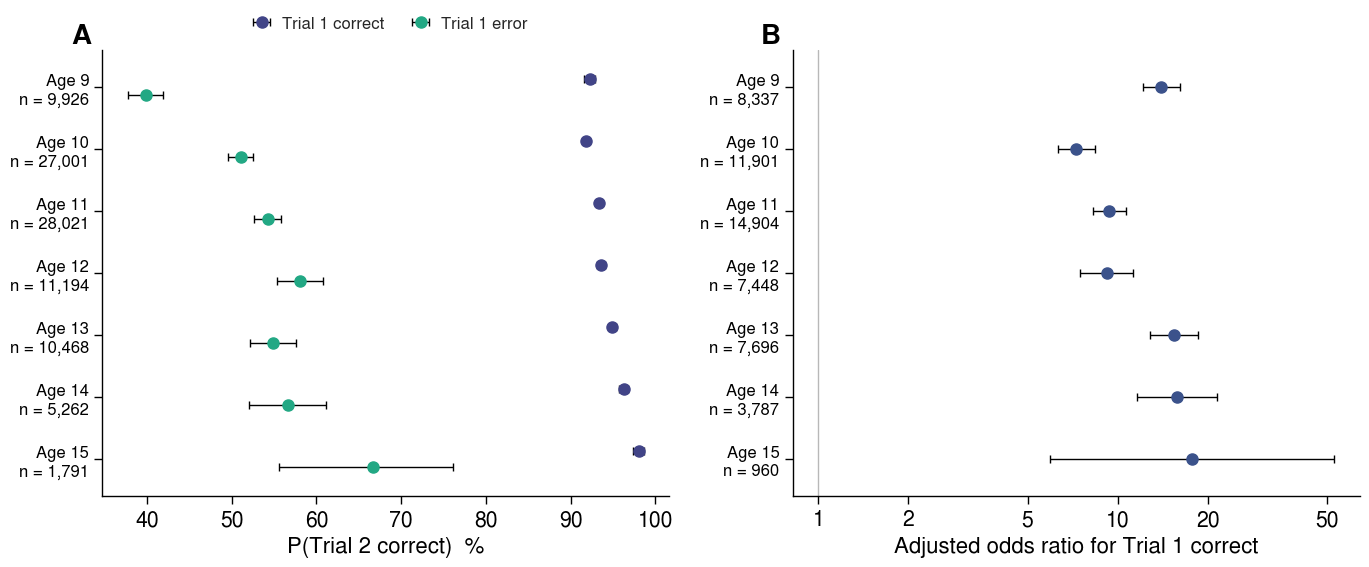

In [20]:
def two_probs(ax, tab, xlabel="P(Trial 2 correct)  %"):
    y = np.arange(len(tab))[::-1]
    for k_, (col, lo, hi, lab_, c) in enumerate([("pC2C1", "C1lo", "C1hi", "Trial 1 correct", C_DIR[0]),
                                                 ("pC2E1", "E1lo", "E1hi", "Trial 1 error", C_DIR[1])]):
        ax.errorbar(tab[col], y + .13 * (1 - 2 * k_),
                    xerr=np.vstack([tab[col] - tab[lo], tab[hi] - tab[col]]),
                    fmt="o", color=c, ecolor="black", elinewidth=1, capsize=3, markersize=8, label=lab_)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{i}\nn = {int(n):,}" for i, n in zip(tab.index, tab.students)], fontsize=FONT_MED - 4)
    ax.set_xlabel(xlabel, fontsize=FONT_MED); ax.set_ylim(-.6, len(tab) - .4)
    ax.legend(fontsize=FONT_MED - 4, frameon=False, loc="upper center", ncol=2,
              bbox_to_anchor=(.5, 1.11), handletextpad=.2, columnspacing=1.2)

def save(fig, stem, axes):
    for ax in np.ravel(axes):
        sns.despine(ax=ax)
    fig.tight_layout(); paint_it_black(axes)
    fig.savefig(PLOTS / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(PLOTS / f"{stem}.png", dpi=300, bbox_inches="tight")
    return fig

def letters(axes):
    for ax, L in zip(np.ravel(axes), "ABCD"):
        ax.text(-.02, 1.06, L, transform=ax.transAxes, fontweight="bold", fontsize=FONT_BIG,
                va="top", ha="right", color="black")

# FIGURE 1 -- by age
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2 = axes
ages = [i for i in desc.index if i.startswith("Age")]
tab = desc.loc[ages]
two_probs(ax1, tab)
ax2.axvline(1, color="#B8B8B8", lw=1)
y = np.arange(len(by_age))[::-1]
ax2.errorbar(by_age.OR, y, xerr=np.vstack([by_age.OR - by_age.lo, by_age.hi - by_age.OR]),
            fmt="o", color=C_ZERO, ecolor="black", elinewidth=1, capsize=3, markersize=8)
ax2.set_yticks(y)
ax2.set_yticklabels([f"Age {int(i)}\nn = {int(n):,}" for i, n in zip(by_age.index, by_age.students)],
                   fontsize=FONT_MED - 4)
ax2.set_xscale("log")
ax2.set_xticks([1, 2, 5, 10, 20, 50]); ax2.set_xticks([], minor=True)
ax2.set_xticklabels(["1", "2", "5", "10", "20", "50"])
ax2.set_xlabel("Adjusted odds ratio for Trial 1 correct", fontsize=FONT_MED)
ax2.set_ylim(-.6, len(by_age) - .4)
letters(axes); save(fig, "seq_zero_by_age", axes); plt.show()

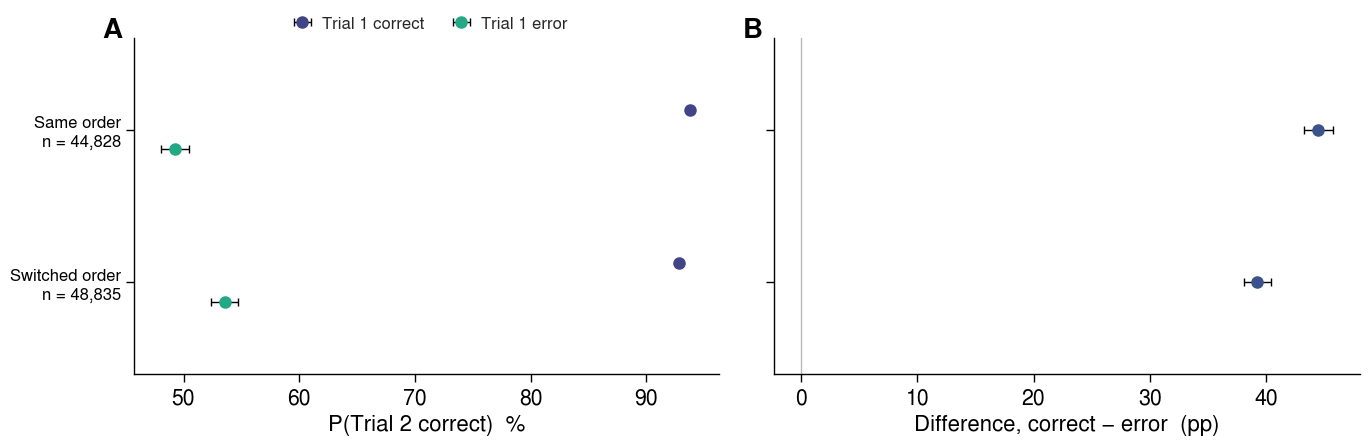

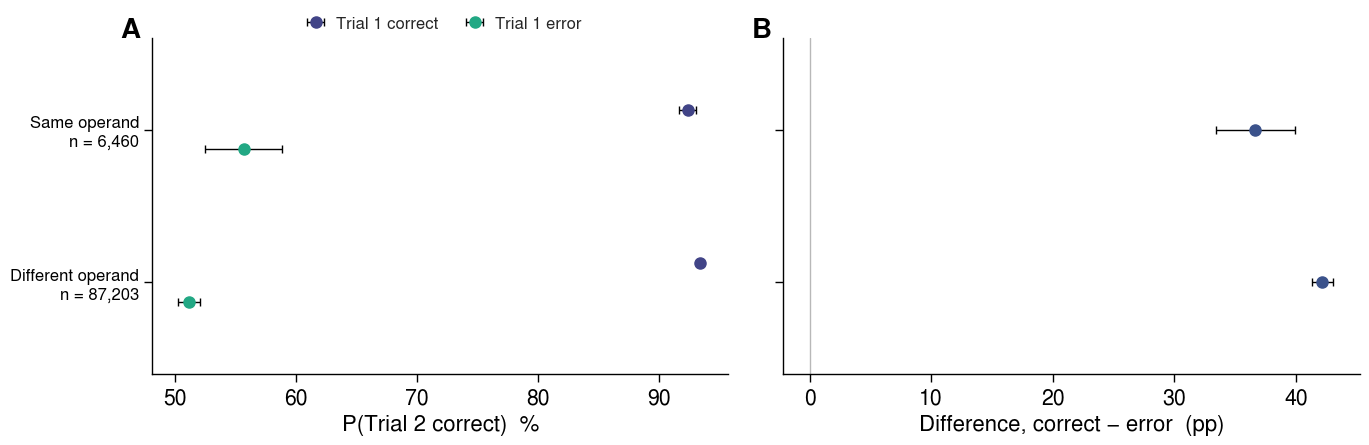

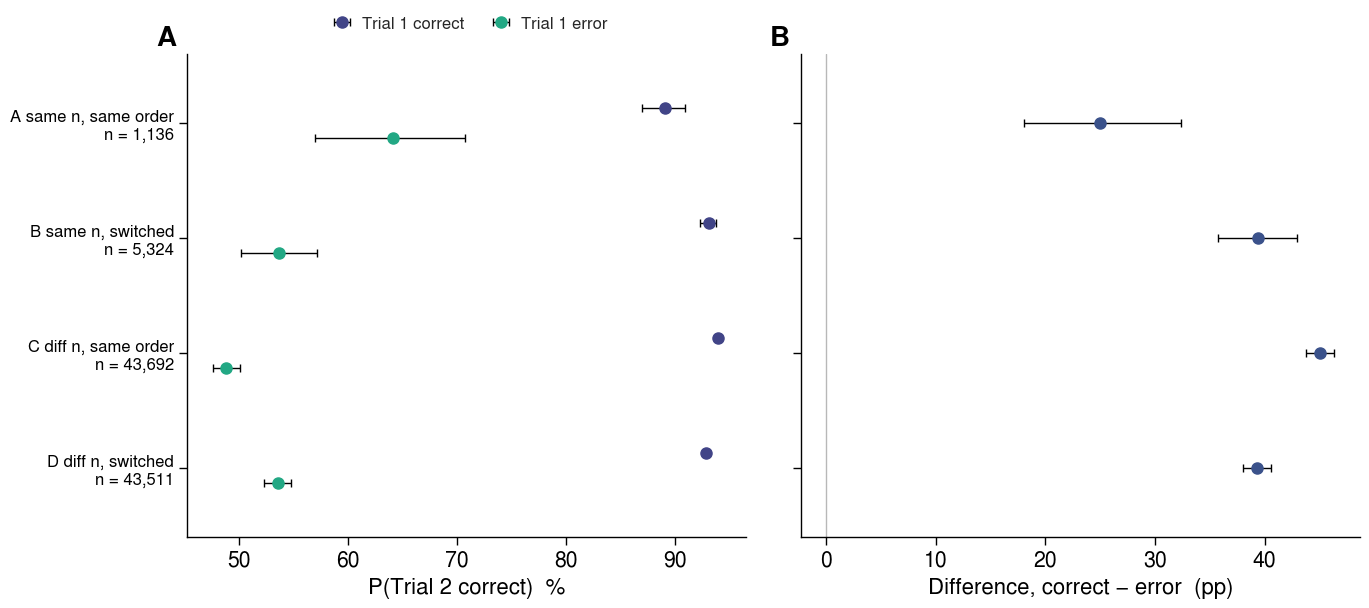

In [21]:
# FIGURES 2, 3, 4 -- order transfer, operand transfer, the four conditions
for stem, tab, title in [("seq_zero_order_transfer", split.loc[["Same order", "Switched order"]],
                          "operand order"),
                         ("seq_zero_operand_transfer", split.loc[["Same operand", "Different operand"]],
                          "non-zero operand"),
                         ("seq_zero_four_conditions", cond, "operand × order")]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.2 + .8 * len(tab)))
    two_probs(axes[0], tab)
    axes[1].axvline(0, color="#B8B8B8", lw=1)
    y = np.arange(len(tab))[::-1]
    axes[1].errorbar(tab["diff"], y, xerr=np.vstack([tab["diff"] - tab.dlo, tab.dhi - tab["diff"]]),
                     fmt="o", color=C_ZERO, ecolor="black", elinewidth=1, capsize=3, markersize=8)
    axes[1].set_yticks(y); axes[1].set_yticklabels([])
    axes[1].set_xlabel("Difference, correct − error  (pp)", fontsize=FONT_MED)
    axes[1].set_ylim(-.6, len(tab) - .4)
    letters(axes); save(fig, stem, axes); plt.show()

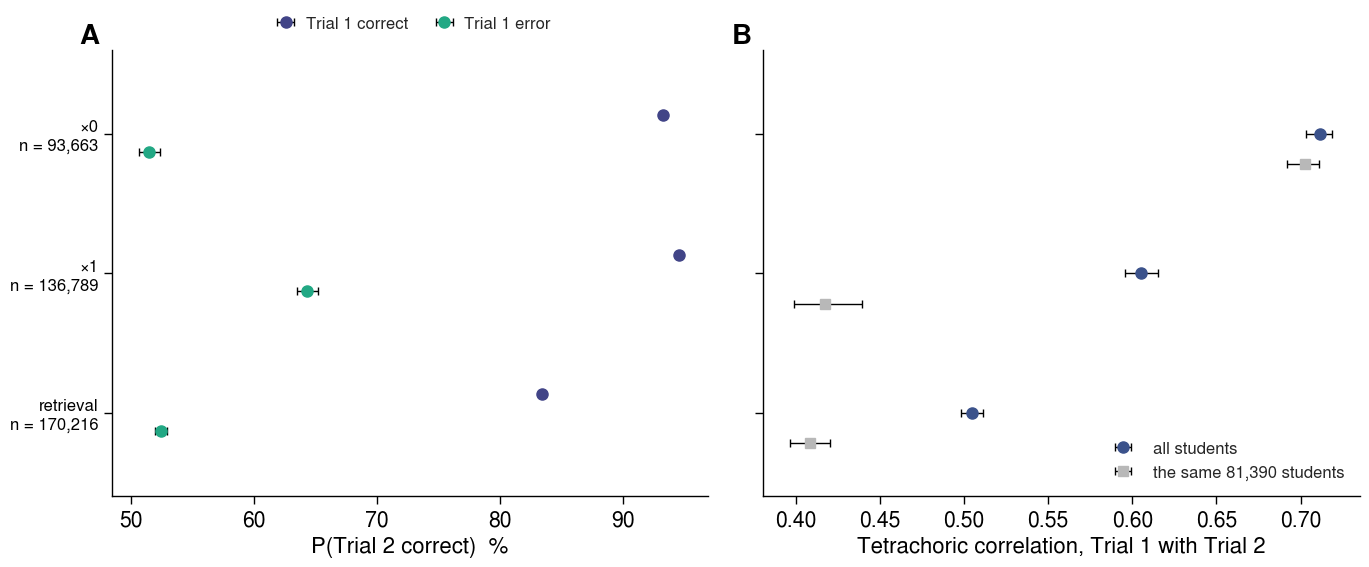

In [22]:
# FIGURE 5 -- ×0 against the 1-table and ordinary retrieval
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
two_probs(axes[0], by_type)
y = np.arange(len(by_type))[::-1]
axes[1].errorbar(by_type.tetra_r, y,
                 xerr=np.vstack([by_type.tetra_r - by_type.t_lo, by_type.t_hi - by_type.tetra_r]),
                 fmt="o", color=C_ZERO, ecolor="black", elinewidth=1, capsize=3, markersize=8,
                 label="all students")
axes[1].errorbar(matched.tetra_r, y - .22,
                 xerr=np.vstack([matched.tetra_r - matched.t_lo, matched.t_hi - matched.tetra_r]),
                 fmt="s", color=C_OTHER, ecolor="black", elinewidth=1, capsize=3, markersize=7,
                 label=f"the same {mt.student.nunique():,} students")
axes[1].set_yticks(y); axes[1].set_yticklabels([])
axes[1].set_xlabel("Tetrachoric correlation, Trial 1 with Trial 2", fontsize=FONT_MED)
axes[1].set_ylim(-.6, len(by_type) - .4)
axes[1].legend(fontsize=FONT_MED - 4, frameon=False, loc="lower right")
letters(axes); save(fig, "seq_problem_type", axes); plt.show()

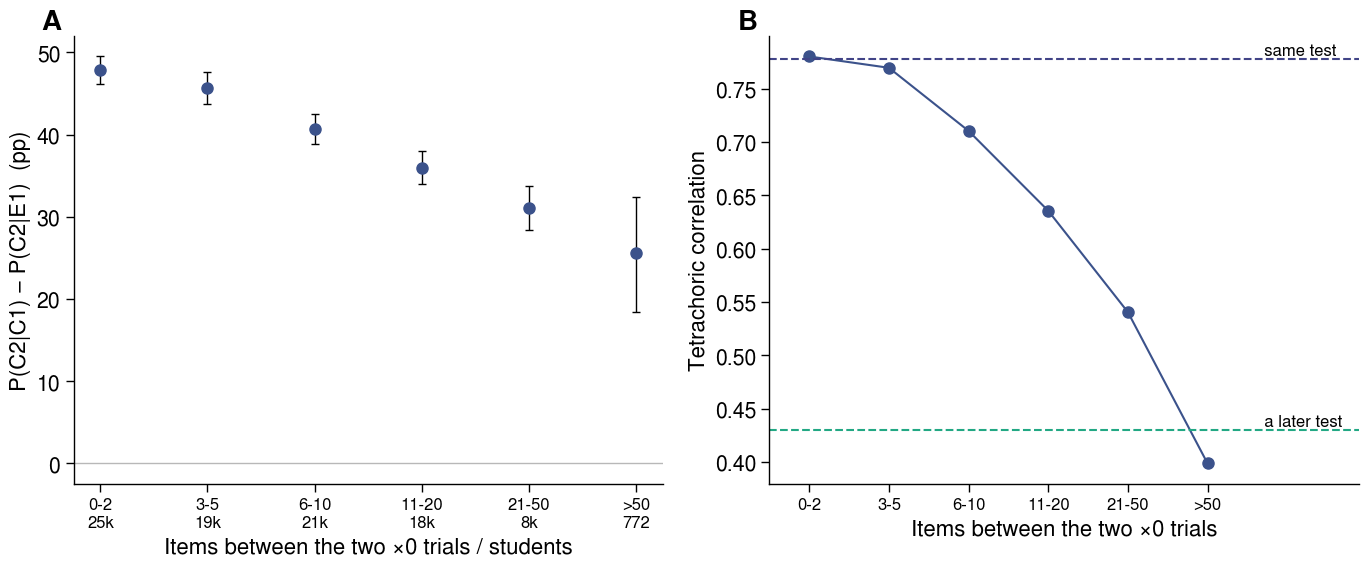

In [23]:
# FIGURE 6 (optional) -- the association against temporal distance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(dist))
axes[0].axhline(0, color="#B8B8B8", lw=1)
axes[0].errorbar(x, dist["diff"], yerr=np.vstack([dist["diff"] - dist.dlo, dist.dhi - dist["diff"]]),
                 fmt="o", color=C_ZERO, ecolor="black", elinewidth=1, capsize=3, markersize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{i}\n{int(n/1000)}k" if n >= 1000 else f"{i}\n{int(n)}"
                         for i, n in zip(dist.index, dist.students)], fontsize=FONT_MED - 4)
axes[0].set_xlabel("Items between the two ×0 trials / students", fontsize=FONT_MED)
axes[0].set_ylabel("P(C2|C1) − P(C2|E1)  (pp)", fontsize=FONT_MED)
axes[1].plot(x, dist.tetra_r, "o-", color=C_ZERO, markersize=8, lw=1.5)
for lab_, val, c in [("same test", sess.loc["Same test", "tetra_r"], C_DIR[0]),
                     ("a later test", sess.loc["A later test", "tetra_r"], C_DIR[1])]:
    axes[1].axhline(val, color=c, lw=1.5, ls="--")
    axes[1].text(len(x) - .4, val, f"  {lab_}", va="bottom", fontsize=FONT_MED - 4, color="black")
axes[1].set_xticks(x); axes[1].set_xticklabels(dist.index, fontsize=FONT_MED - 4)
axes[1].set_xlabel("Items between the two ×0 trials", fontsize=FONT_MED)
axes[1].set_ylabel("Tetrachoric correlation", fontsize=FONT_MED)
axes[1].set_xlim(-.5, len(x) + .9)
letters(axes); save(fig, "seq_temporal_distance", axes); plt.show()

## 17. Summary

`N students` and `N transitions` are separated everywhere: the primary rows are one pair per student,
the all-transitions rows are not.

In [24]:
def line(analysis, students, transitions, measure, est, lo, hi, p):
    return dict(analysis=analysis, N_students=students, N_transitions=transitions, measure=measure,
                estimate=est, lo=lo, hi=hi, p=p)

f4 = r_full.tidy().loc["c1"]; f5 = lg(FULL + " + c1:age_c", m).tidy().loc["c1:age_c"]
f6 = lg(FULL + " + same_order + c1:same_order", m).tidy().loc["c1:same_order"]
f7 = lg(FULL + " + same_order + same_operand + c1:same_operand", m).tidy().loc["c1:same_operand"]
fD = cond_adj.loc["D diff n, switched"]
f9 = r3.tidy().loc["c1:t_ret"]
f12 = rt_c1
f14 = r_all.tidy().loc["c1"]
S = pd.DataFrame([
    line("Raw P(C2|C1) − P(C2|E1)", f"{int(overall.students):,}", f"{int(overall.students):,}", "pp",
         overall["diff"], overall.dlo, overall.dhi, np.nan),
    line("Adjusted logistic", f"{r_full._N:,}", f"{r_full._N:,}", "OR",
         np.exp(f4["Estimate"]), np.exp(f4["2.5%"]), np.exp(f4["97.5%"]), f4["Pr(>|t|)"]),
    line("Trial1 × age", f"{r_full._N:,}", f"{r_full._N:,}", "OR per year",
         np.exp(f5["Estimate"]), np.exp(f5["2.5%"]), np.exp(f5["97.5%"]), f5["Pr(>|t|)"]),
    line("Trial1 × same order", f"{r_full._N:,}", f"{r_full._N:,}", "OR ratio",
         np.exp(f6["Estimate"]), np.exp(f6["2.5%"]), np.exp(f6["97.5%"]), f6["Pr(>|t|)"]),
    line("Trial1 × same operand", f"{r_full._N:,}", f"{r_full._N:,}", "OR ratio",
         np.exp(f7["Estimate"]), np.exp(f7["2.5%"]), np.exp(f7["97.5%"]), f7["Pr(>|t|)"]),
    line("Different operand + switched order", f"{int(fD.students):,}", f"{int(fD.students):,}", "OR",
         fD.OR, fD.lo, fD.hi, fD.p),
    line("×0 vs retrieval (interaction)", f"{d3.student.nunique():,}", f"{len(d3):,}", "OR ratio",
         np.exp(f9["Estimate"]), np.exp(f9["2.5%"]), np.exp(f9["97.5%"]), f9["Pr(>|t|)"]),
    line("×0 vs retrieval (tetrachoric)", f"{mt.student.nunique():,}", f"{3*mt.student.nunique():,}",
         "Δr", matched.loc["×0", "tetra_r"] - matched.loc["retrieval", "tetra_r"], np.nan, np.nan, np.nan),
    line("Trial 2 RT | Trial 2 correct", f"{len(q):,}", f"{len(q):,}", "ms",
         to_ms(f12["Estimate"]), to_ms(f12["2.5%"]), to_ms(f12["97.5%"]), f12["Pr(>|t|)"]),
    line("All transitions, pooled logit", f"{ad.student.nunique():,}", f"{r_all._N:,}", "OR",
         np.exp(f14["Estimate"]), np.exp(f14["2.5%"]), np.exp(f14["97.5%"]), f14["Pr(>|t|)"]),
    line("All transitions, GEE population-averaged", f"{gee_or[3]:,}", f"{gee_or[4]:,}", "OR",
         gee_or[0], gee_or[1], gee_or[2], np.nan),
]).set_index("analysis")
display(S.round({"estimate": 3, "lo": 3, "hi": 3, "p": 8}))

,N_students,N_transitions,measure,estimate,lo,hi,p
analysis,,,,,,,
Raw P(C2|C1) − P(C2|E1),"93,663","93,663",pp,41.790,40.924,42.656,NaN
Adjusted logistic,"55,033","55,033",OR,10.654,9.975,11.380,0.000000
Trial1 × age,"55,033","55,033",OR per year,1.006,0.962,1.052,0.795589
Trial1 × same order,"55,033","55,033",OR ratio,1.364,1.200,1.550,0.000002
Trial1 × same operand,"55,033","55,033",OR ratio,0.783,0.608,1.009,0.058481
Different operand + switched order,"25,648","25,648",OR,9.036,8.222,9.931,0.000000
×0 vs retrieval (interaction),"96,654","244,428",OR ratio,0.225,0.206,0.245,0.000000
×0 vs retrieval (tetrachoric),"81,390","244,170",Δr,0.294,NaN,NaN,NaN
Trial 2 RT | Trial 2 correct,"49,134","49,134",ms,-352.708,-386.976,-317.905,0.000000


## 19. What this does and does not say

**RQ1 — do students who get the first `×0` problem right get the second one right?** Yes, and the gap
is very large: 93.3% against 51.5%, a difference of 41.8 pp [40.9, 42.7], OR 13.1 [12.5, 13.7],
93,663 students.

**RQ2 — does it survive controlling for proficiency and speed?** Yes. Adjusted for general
multiplication accuracy, general log RT, age, Trial-1 RT, the Trial-2 operand and its order, and the
distance between the two trials, OR 10.7 [10.0, 11.4]: a predicted 93.8% after a correct first trial
against 61.3% after an error, +32.5 pp. It also holds inside every within-age proficiency quintile
(adjusted OR 8.1 to 13.3) and every speed quintile, so it is not a proxy for being a strong student.

**RQ3 — does it generalise to a different non-zero operand?** Yes, completely. The association is
*not* weaker when the operand changes; the interaction points the other way (OR 0.78 [0.61, 1.01],
p = .058, i.e. weaker when the operand *repeats*).

**RQ4 — does it survive a change of order?** Yes, somewhat attenuated: OR 15.6 with the order
preserved against 11.2 with it switched, interaction 1.36 [1.20, 1.55], p < .001.

**RQ5 — does it survive both changing?** Yes. `0×7 → 4×0`, where neither the fact nor the format
repeats, gives a raw OR of 11.2 [10.5, 11.9] and an adjusted 9.0 [8.2, 9.9], +30.2 pp — 43,511
students, the largest of the four cells. The *weakest* cell is the opposite one: the same fact
repeated in the same order (OR 4.6 raw, 2.5 adjusted, 1,136 students). Whatever produces the
association, it is not repetition of a specific fact.

**RQ6 — is it stronger than for ordinary multiplication?** Yes, and this is the load-bearing result.
On the 81,390 students who contribute a first pair of all three kinds, the tetrachoric correlation
is .70 for `×0`, .42 for the 1-table and .41 for retrieval facts; in the pooled adjusted model the
`×0 × retrieval` interaction is OR 0.23 [0.21, 0.24], p < .001. Odds ratios across types are not
scale-free — the three differ in base accuracy — which is why the tetrachoric is the headline.

**RQ7 — does it vary with age?** No. The `Trial1 × age` interaction is OR 1.006 [0.96, 1.05] per
year, p = .80, even though the age-specific ORs range from 7.3 to 17.7. Reading a developmental
trend off those per-age numbers would be reading noise.

**RQ8 — does temporal distance matter?** Yes, a lot, but it does not explain the effect away. The
tetrachoric falls from .78 within 2 items to .40 beyond 50; within one test it is .78, across tests
.43. Those across-test pairs are a median 102 days apart and still show +22.1 pp, OR 4.1. Inside the
across-test pairs the gap in days adds nothing (p = .17). So there is a short-lag component —
attention, task state, warm-up — sitting on top of a component that survives months and a different
test.

**RQ9 — is a correct Trial 2 also faster?** Yes: among students who get Trial 2 right, having had
Trial 1 right predicts −353 ms [−387, −318], −13.7% against a 2.58 s baseline, unchanged when
Trial-1 RT is also held. Fluency moves with correctness, not only eventual correctness.

**RQ10 — could feedback explain it?** No. A998 shows nothing after a wrong answer (`DECISIONS #39`),
and the platform does not adaptively re-present the item either: the next `×0` problem is the same
directed fact 1.2% of the time after a correct answer and 1.4% after an error, at the same median
distance.

### How far this can be pushed

`P(C2|C1) > P(C2|E1)` on its own shows only that the two trials measure something shared. Six
of the criteria in the brief are met — the association survives the controls, survives a change of
operand, survives a change of order, survives both at once, is much larger for `×0` than for
ordinary retrieval, and survives months and a change of test session. That is **evidence consistent
with a stable, generalisable representation of the zero rule**, and it is not consistent with exact
fact repetition, order-specific priming, feedback, or general proficiency.

It is **not** evidence that answering Trial 1 correctly caused anything, and the design cannot
separate stable between-student differences from genuine trial-to-trial carry-over: a lagged outcome
with a student effect is not identified here (section 14). The safe phrasing for the paper is that
knowing the zero rule is close to an all-or-nothing student-level property — the split-half result
sharpens this: `×0` accuracy is no more stable as a *rate* than retrieval accuracy, but individual
`×0` trials are far more tightly coupled to each other, which is what a rule looks like next to
item-by-item recall.

Two limits to carry into `DECISIONS.txt`: the 41% of students without a proficiency control (fewer
than 20 non-`×0` trials) are dropped from every adjusted model, and they are the students with the
shortest tests; and `0×1` / `1×0` sit in both rule families, counted here as `×0` (`DECISIONS #36`).

## 18. Sanity checks

In [25]:
assert z0.groupby(["student", "course_age"]).size().max() == 1, "a student contributes more than one primary pair"
assert z0.pair_no.eq(1).all() and z0.ptype_c.eq(0).all()
assert not ((z0.a1 == 0) & (z0.b1 == 0)).any() and not ((z0.a2 == 0) & (z0.b2 == 0)).any()   # 0×0 out (#15)
assert z0.course_age.min() >= 9, "age 8 has no ×0 items (#12)"
assert (z0.trials_between >= 0).all() and (z0.gap_days >= 0).all(), "a pair is out of order"
assert trials.loc[trials.ptype_c == 0, "n_op"].between(1, 9).all()
assert np.isclose(overall.pC2C1, 100 * z0.loc[z0.c1 == 1, "c2"].mean())
assert abs(desc.loc["All ages", "OR"] - (lambda x: x[0] * x[3] / (x[1] * x[2]))(
    [((z0.c1 == 1) & (z0.c2 == 1)).sum(), ((z0.c1 == 1) & (z0.c2 == 0)).sum(),
     ((z0.c1 == 0) & (z0.c2 == 1)).sum(), ((z0.c1 == 0) & (z0.c2 == 0)).sum()])) < 1e-6
print(f"{len(z0):,} primary pairs | {len(pairs):,} transitions | "
      f"{z0.student.nunique():,} students | {z0.classroom.nunique():,} classrooms")
print("the four transfer cells:", {k_: int(v) for k_, v in z0.cond4.value_counts().items()})

93,663 primary pairs | 2,771,945 transitions | 93,663 students | 6,874 classrooms
the four transfer cells: {'C diff n, same order': 43692, 'D diff n, switched': 43511, 'B same n, switched': 5324, 'A same n, same order': 1136}
